In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
from pathlib import Path
from matplotlib import rc
from matplotlib.ticker import FuncFormatter

In [2]:
#rc("font", **{"family": "serif", "serif": ["Times"], "size": 15})
rc("text", usetex=False)

In [3]:
BASE = Path("./juicepress_results_corpus_j/reports")

In [4]:
raw = {
    "identifier": [], # tree_id + elf name
    "juiciness": [],
    "bucket": [],
    "confidence_file_not_in_buildroot": [],
    "confidence_file_not_in_alpine_repos": [],
    "keyword_in_binary": [],
    "file_not_in_nsrl": [],
    "confidence_file_not_in_openwrt_repos": [],
    "keyword_in_filename": [],
    "confidence_file_not_in_ptxdist_distrokit": [],
    "confidence_file_not_in_ubuntu_repos": [],
    "known_taint_symbol": [],
    "not_in_ubuntu_manpages": [],
    "confidence_file_not_in_openembedded_layers": []
}

rayon_keys = set(["keyword_in_binary", "known_taint_symbol", "keyword_in_filename"])

for i, p_report in enumerate(BASE.glob("*juicepress-masked.json")):
    tree_id = p_report.stem.split("___")[2]
    data = json.loads(p_report.read_text())
    for result in data["results"]:
        raw["identifier"] += [f"{tree_id}_{result['sha256']}"]
        raw["juiciness"] += [result["juiciness"]]
        raw["bucket"] += [int(round(result["juiciness"], 0))]
        for key, r in result["ranking_by_factor"].items():
            raw[key] += [r["result"]]
df = pd.DataFrame(raw)

In [5]:
from matplotlib.colors import LinearSegmentedColormap


palette = sns.color_palette("colorblind")
blue = palette[0]    # blue
lightblue = palette[-1]
orange = palette[1]  # orange
yellow = "#ECE133"
red = palette[3]     # red from colorblind palette

# Create continuous colormap: blue -> orange -> red
cmap = LinearSegmentedColormap.from_list("blue_orange_red_yellow", [blue, red, orange, yellow])

In [6]:
counts = df.groupby("bucket").count()["identifier"]
buckets = list(range(12))

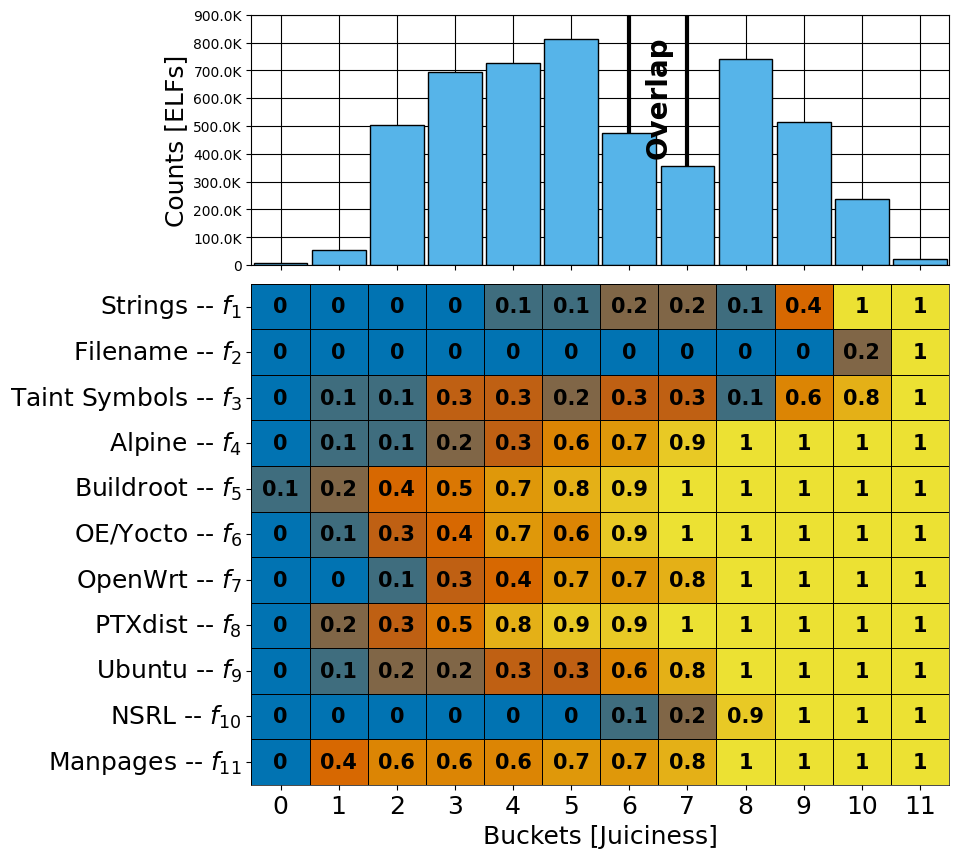

In [7]:
fig = plt.figure(figsize=(9, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 4], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1])

# bar plot, my friends.
ax_top.bar(buckets, counts, width=0.925, color=lightblue, linewidth=1, edgecolor="black")
ax_top.set_xlim(-0.5, 11.5)
ax_top.set_xticks(buckets)
ax_top.set_xticklabels(buckets, fontsize=18)
ax_top.tick_params(axis="x", labelbottom=False)
ax_top.set_ylabel("Counts [ELFs]", fontsize=18)
ax_top.set_ylim(0, 900_000)
ax_top.axvline(6, linewidth=3, color="black", linestyle="-", zorder=-3)
ax_top.axvline(7, linewidth=3, color="black", linestyle="-", zorder=-3)

ax_top.text(6.5, 825_000, "Overlap", color="black", fontweight="heavy", fontsize=20, ha="center", va="top", rotation=90)


def k_m_formatter(x, pos):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return str(int(x))

ax_top.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))

ax_top.set_axisbelow(True)
ax_top.grid(True, zorder=-5, color="black")

genes = df.drop(columns=["identifier", "juiciness"]).rename(columns={
    "confidence_file_not_in_buildroot": "Buildroot",
    "confidence_file_not_in_alpine_repos": "Alpine",
    "keyword_in_binary": "Strings",
    "file_not_in_nsrl": "NSRL",
    "confidence_file_not_in_openwrt_repos": "OpenWrt",
    "keyword_in_filename": "Filename",
    "confidence_file_not_in_ptxdist_distrokit": "PTXdist",
    "confidence_file_not_in_ubuntu_repos": "Ubuntu",
    "known_taint_symbol": "Taint Symbols",
    "not_in_ubuntu_manpages": "Manpages",
    "confidence_file_not_in_openembedded_layers": "OE/Yocto"
}).groupby("bucket").mean()

genes = genes[["Strings", "Filename", "Taint Symbols", "Alpine", "Buildroot", "OE/Yocto", "OpenWrt", "PTXdist", "Ubuntu", "NSRL", "Manpages"]].round(1).T

# ------------------------
# BOTTOM: heatmap BUT forced alignment
# ------------------------
sns.heatmap(
    genes,
    ax=ax_bottom,
    cmap=cmap,
    cbar=False,
    cbar_kws={
        "orientation": "horizontal",
        "pad": 0.125,
        #"edgecolor": "black",
        #"shrink": 1.1,
    },
    xticklabels=buckets,
    yticklabels=True,
    linecolor="black",  # border color for each patch
    linewidth=0.5,       # thickness of the border
    annot=True
)

for spine in ax_bottom.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor("black")

# IMPORTANT: align heatmap cells with bar centers
ax_bottom.set_xlim(0, 12)

# force tick alignment (center of cells)
ax_bottom.set_xticks(np.arange(12) + 0.5)
ax_bottom.set_xticklabels(buckets, fontsize=18)

ytick_labels = [f"{name.get_text()} -- $f_{{{n+1}}}$" for n, name in enumerate(ax_bottom.get_yticklabels())]
ax_bottom.set_yticklabels(ytick_labels, fontsize=18)


ax_bottom.set_xlabel("Buckets [Juiciness]", fontsize=18)
#ax_bottom.set_ylabel("Factors")

for text in ax_bottom.texts:
    text.set_fontsize(15)
    text.set_fontweight("heavy")
    text.set_color("black")

plt.savefig("juicepress_factor_breakdown.pdf", bbox_inches="tight")

plt.show()